# Food Delivery ETA Prediction — Random Forest + XGBoost Ensemble

**Goal:** improve delivery-time (`Time_taken (min)`) prediction accuracy by combining two complementary
tree-based regressors.

| Model | How it learns | What it reduces |
|---|---|---|
| **Random Forest** | averages many independent trees (**bagging**) | **variance** |
| **XGBoost** | sequentially corrects previous errors (**boosting**) | **bias** |

Because their errors are not identical, blending them can generalise better than either alone.

### Two rules we never break
1. **No data leakage** — every fitted transform (imputation, one-hot encoding) lives *inside* each model's
   `Pipeline`, so during cross-validation it is refit on each fold's training data only. Ensemble weights and
   the stacking meta-model are chosen on **out-of-fold predictions**, so the test set is never used to make a
   modelling decision.
2. **No overfitting** — both models are regularised and tuned with cross-validation, and we report the
   **train-vs-test gap** for every model.

### Pipeline
```
                    Load Dataset
                          |
                 Data Cleaning
                          |
              Feature Engineering  (distance, prep time, order hour, peak hour, ...)
                          |
               Train / Test Split (80 / 20)
                          |
        +-----------------+-----------------+
        v                                   v
   Random Forest                        XGBoost
  (tune via CV)                       (tune via CV)
        |                                   |
        +----------------+------------------+
                         v
     Ensemble  (weighted average + Ridge stacking, weights chosen by CV)
                         |
              Evaluate MAE, RMSE, R2
                         |
          Save best model + prediction CSV
```

## Setup

In [1]:
import time, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "Zomato Dataset.csv"                 # dataset sits next to this notebook
OUT = Path("outputs_ensemble")
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "models").mkdir(parents=True, exist_ok=True)
print("Setup complete.  XGBoost", __import__('xgboost').__version__)

Setup complete.  XGBoost 3.3.0


## Phase 1 — Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH).drop_duplicates().reset_index(drop=True)
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
print(f"Columns with missing values: {int((df.isna().sum() > 0).sum())}")
df.head()

Rows: 45,584   Columns: 20
Columns with missing values: 8


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


## Phase 2 — Data Cleaning & Feature Engineering

All steps here are **row-wise** (each row uses only its own values or fixed domain constants), so they are
leakage-free and safe to run before the split. Statistical steps that *learn* from the data
(imputation, encoding) are deferred to the model pipelines below.

- **`distance_km`** — haversine distance. We take `abs()` of the coordinates (India is entirely +lat/+lon, but
  the raw data contains sign-flipped and near-zero placeholder GPS points) and cap at 30 km.
- **`prep_time_min`** — pickup time minus order time, with midnight wrap-around handled.
- **`order_hour`, `is_peak_hour`, `time_of_day`** — temporal demand signals.
- **`order_day_of_week`, `is_weekend`** — calendar signals.
- Ratings are clipped to their valid 1–5 range (the raw data has a stray 6.0).

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

def time_of_day(h):
    if pd.isna(h): return "Unknown"
    h = int(h)
    if 5 <= h <= 11:  return "Morning"
    if 12 <= h <= 16: return "Afternoon"
    if 17 <= h <= 21: return "Evening"
    return "Night"

df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].clip(1, 5)

df["distance_km"] = haversine_km(
    df.Restaurant_latitude.abs(),  df.Restaurant_longitude.abs(),
    df.Delivery_location_latitude.abs(), df.Delivery_location_longitude.abs()
).clip(0, 30)

t_order  = pd.to_datetime(df.Time_Orderd,       format="%H:%M", errors="coerce")
t_picked = pd.to_datetime(df.Time_Order_picked, format="%H:%M", errors="coerce")
prep = (t_picked - t_order).dt.total_seconds() / 60
prep = prep.where(prep >= 0, prep + 1440)                 # crossed midnight
df["prep_time_min"] = prep.mask((prep < 0) | (prep > 120))  # implausible -> NaN (imputed later)

hour = t_order.dt.hour.fillna(t_picked.dt.hour)
df["order_hour"]   = t_order.dt.hour
df["pickup_hour"]  = t_picked.dt.hour
df["is_peak_hour"] = hour.isin([12, 13, 14, 19, 20, 21, 22]).astype(int)
df["time_of_day"]  = hour.apply(time_of_day)

order_date = pd.to_datetime(df.Order_Date, format="%d-%m-%Y", errors="coerce")
df["order_day_of_week"] = order_date.dt.dayofweek
df["is_weekend"] = (order_date.dt.dayofweek >= 5).astype(int)

df[["distance_km", "prep_time_min", "order_hour", "is_peak_hour", "time_of_day", "is_weekend"]].head()

,distance_km,prep_time_min,order_hour,is_peak_hour,time_of_day,is_weekend
0,10.280596,15.0,21.0,1,Evening,1
1,6.242327,10.0,14.0,1,Afternoon,1
2,13.787879,10.0,17.0,0,Evening,0
3,2.930262,10.0,9.0,0,Morning,1
4,19.396645,15.0,19.0,1,Evening,0


## Phase 3 — Feature Selection, Train/Test Split & Leakage-Safe Preprocessing

In [4]:
TARGET = "Time_taken (min)"
numeric_features = ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries", "distance_km",
                    "prep_time_min", "order_hour", "pickup_hour", "order_day_of_week", "is_weekend", "is_peak_hour"]
categorical_features = ["Weather_conditions", "Road_traffic_density", "Vehicle_condition", "Type_of_order",
                        "Type_of_vehicle", "Festival", "City", "time_of_day"]

X = df[numeric_features + categorical_features].copy()
X["Vehicle_condition"] = X["Vehicle_condition"].astype(str)   # condition rating -> categorical
y = df[TARGET].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}    Test: {len(X_test):,}")

# Preprocessing goes INSIDE each pipeline: refit per CV fold -> no leakage into tuning / weighting / stacking.
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     categorical_features),
])

Train: 36,467    Test: 9,117


## Step 1 — Train & Tune Both Models Independently

### 1a. Random Forest
Tuned over `n_estimators`, `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`.
`min_samples_leaf` and `max_features < 1.0` are the key **anti-overfitting** knobs.

In [5]:
rf_pipe = Pipeline([("prep", preprocessor),
                    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
rf_param = {
    "model__n_estimators":      [200, 300],
    "model__max_depth":         [12, 16, 20],
    "model__min_samples_leaf":  [1, 2, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features":      ["sqrt", 0.5],
}
rf_search = RandomizedSearchCV(rf_pipe, rf_param, n_iter=6, cv=3,
                               scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=1)
t = time.time(); rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print(f"RF tuned in {time.time()-t:.0f}s")
print("best params:", {k.replace('model__', ''): v for k, v in rf_search.best_params_.items()})
print(f"CV MAE: {-rf_search.best_score_:.3f} min")

RF tuned in 32s
best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 16}
CV MAE: 3.112 min


### 1b. XGBoost
Tuned over `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `min_child_weight`,
`reg_lambda`. `subsample`/`colsample_bytree` (row/column sampling) plus `reg_lambda` control overfitting.

> **Early stopping** is the other classic XGBoost technique: fit with a validation `eval_set` and
> `early_stopping_rounds` to auto-pick the number of trees. We tune `n_estimators` directly here so the whole
> search stays inside one clean cross-validated object; a commented example of early stopping is included at the
> end of the notebook.

In [6]:
xgb_pipe = Pipeline([("prep", preprocessor),
                     ("model", XGBRegressor(objective="reg:squarederror", tree_method="hist",
                                            random_state=RANDOM_STATE, n_jobs=-1))])
xgb_param = {
    "model__n_estimators":     [300, 500, 700],
    "model__learning_rate":    [0.03, 0.05, 0.1],
    "model__max_depth":        [4, 6, 8],
    "model__subsample":        [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_lambda":       [1.0, 5.0, 10.0],
}
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_param, n_iter=10, cv=3,
                                scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=1)
t = time.time(); xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print(f"XGB tuned in {time.time()-t:.0f}s")
print("best params:", {k.replace('model__', ''): v for k, v in xgb_search.best_params_.items()})
print(f"CV MAE: {-xgb_search.best_score_:.3f} min")

XGB tuned in 45s
best params: {'subsample': 0.85, 'reg_lambda': 10.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
CV MAE: 3.119 min


## Step 2 — Validate Each Model Individually (held-out test set)

In [7]:
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

rf_test  = best_rf.predict(X_test)
xgb_test = best_xgb.predict(X_test)

def scores(name, y_true, pred):
    return {"Model": name,
            "MAE":  mean_absolute_error(y_true, pred),
            "RMSE": root_mean_squared_error(y_true, pred),
            "R2":   r2_score(y_true, pred)}

pd.DataFrame([scores("Random Forest", y_test, rf_test),
              scores("XGBoost",       y_test, xgb_test)]).round(4)

,Model,MAE,RMSE,R2
0,Random Forest,3.1252,3.9311,0.8248
1,XGBoost,3.1405,3.9550,0.8227


## Step 3 — Weighted-Average Ensemble (weights chosen by cross-validation)

We do **not** guess the weights, and we do **not** tune them on the test set. Instead we generate
**out-of-fold (OOF)** predictions on the *training* data — each row predicted by a model that never saw it —
and pick the weight that minimises OOF MAE.

In [8]:
rf_oof  = cross_val_predict(best_rf,  X_train, y_train, cv=5, n_jobs=1)
xgb_oof = cross_val_predict(best_xgb, X_train, y_train, cv=5, n_jobs=1)

weights = np.linspace(0, 1, 21)
oof_mae = [mean_absolute_error(y_train, w * rf_oof + (1 - w) * xgb_oof) for w in weights]
best_w  = float(weights[int(np.argmin(oof_mae))])
print(f"Best RF weight = {best_w:.2f}   (XGB weight = {1 - best_w:.2f})   OOF MAE = {min(oof_mae):.4f}")

pd.DataFrame({"RF_weight": weights.round(2), "XGB_weight": (1 - weights).round(2),
              "OOF_MAE": np.round(oof_mae, 4)}).iloc[::4]

Best RF weight = 0.55   (XGB weight = 0.45)   OOF MAE = 3.0808


,RF_weight,XGB_weight,OOF_MAE
0,0.0,1.0,3.1056
4,0.2,0.8,3.0905
8,0.4,0.6,3.0824
12,0.6,0.4,3.0812
16,0.8,0.2,3.0866
20,1.0,0.0,3.0987


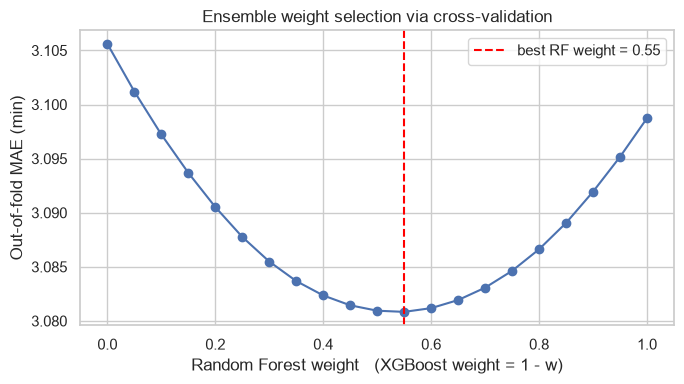

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(weights, oof_mae, marker="o")
plt.axvline(best_w, color="red", ls="--", label=f"best RF weight = {best_w:.2f}")
plt.xlabel("Random Forest weight   (XGBoost weight = 1 - w)")
plt.ylabel("Out-of-fold MAE (min)")
plt.title("Ensemble weight selection via cross-validation")
plt.legend(); plt.tight_layout()
plt.savefig(OUT / "figures" / "weight_selection.png", dpi=120); plt.show()

## Step 3 (advanced) — Stacking with a Ridge meta-model

Instead of a fixed weight, let a small linear model **learn** how to combine the two base predictions. It is
trained on the same OOF predictions, so it also never sees the test set during fitting.

In [10]:
stacker = Ridge().fit(np.c_[rf_oof, xgb_oof], y_train)
print(f"Ridge meta-model:  RF coef = {stacker.coef_[0]:.3f}   XGB coef = {stacker.coef_[1]:.3f}   "
      f"intercept = {stacker.intercept_:.3f}")

Ridge meta-model:  RF coef = 0.542   XGB coef = 0.469   intercept = -0.293


## Step 4 — Evaluate Random Forest vs XGBoost vs Ensemble vs Stacking

In [11]:
ens_test = best_w * rf_test + (1 - best_w) * xgb_test
stk_test = stacker.predict(np.c_[rf_test, xgb_test])

results = pd.DataFrame([
    scores("Random Forest",                                   y_test, rf_test),
    scores("XGBoost",                                         y_test, xgb_test),
    scores(f"Weighted Ensemble (RF {best_w:.2f}/XGB {1-best_w:.2f})", y_test, ens_test),
    scores("Stacking (Ridge meta-model)",                     y_test, stk_test),
]).sort_values("MAE").reset_index(drop=True)
results.to_csv(OUT / "model_comparison.csv", index=False)

print("Overfitting check (train R2 -> test R2, smaller gap = better generalisation):")
for name, mdl in [("Random Forest", best_rf), ("XGBoost", best_xgb)]:
    tr = r2_score(y_train, mdl.predict(X_train)); te = r2_score(y_test, mdl.predict(X_test))
    print(f"  {name:14} {tr:.3f} -> {te:.3f}   gap {tr - te:.3f}")

results.round(4)

Overfitting check (train R2 -> test R2, smaller gap = better generalisation):


  Random Forest  0.897 -> 0.825   gap 0.072


  XGBoost        0.874 -> 0.823   gap 0.052


,Model,MAE,RMSE,R2
0,Stacking (Ridge meta-model),3.1137,3.9149,0.8263
1,Weighted Ensemble (RF 0.55/XGB 0.45),3.1141,3.9160,0.8262
2,Random Forest,3.1252,3.9311,0.8248
3,XGBoost,3.1405,3.9550,0.8227


## Visualisations

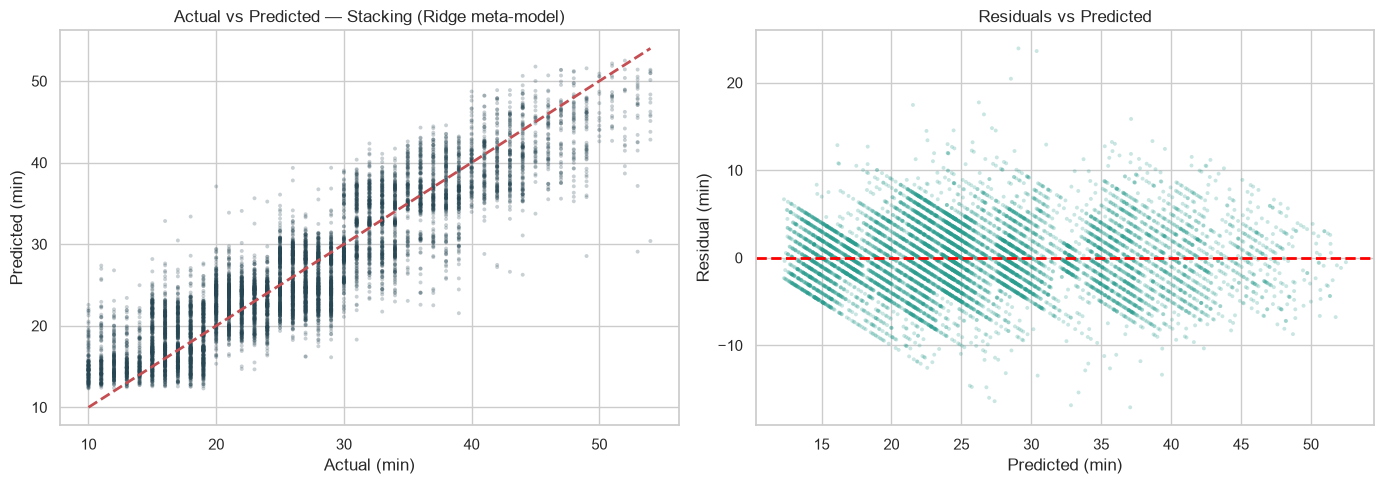

In [12]:
best_name = results.iloc[0]["Model"]
best_pred = stk_test if "Stacking" in best_name else ens_test

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
lims = [y_test.min(), y_test.max()]
ax[0].scatter(y_test, best_pred, s=8, alpha=0.25, edgecolor="none", color="#264653")
ax[0].plot(lims, lims, "r--", lw=2)
ax[0].set_title(f"Actual vs Predicted — {best_name}")
ax[0].set_xlabel("Actual (min)"); ax[0].set_ylabel("Predicted (min)")

res = y_test.values - best_pred
ax[1].scatter(best_pred, res, s=8, alpha=0.25, edgecolor="none", color="#2a9d8f")
ax[1].axhline(0, color="red", ls="--", lw=2)
ax[1].set_title("Residuals vs Predicted")
ax[1].set_xlabel("Predicted (min)"); ax[1].set_ylabel("Residual (min)")
plt.tight_layout(); plt.savefig(OUT / "figures" / "ensemble_diagnostics.png", dpi=120); plt.show()

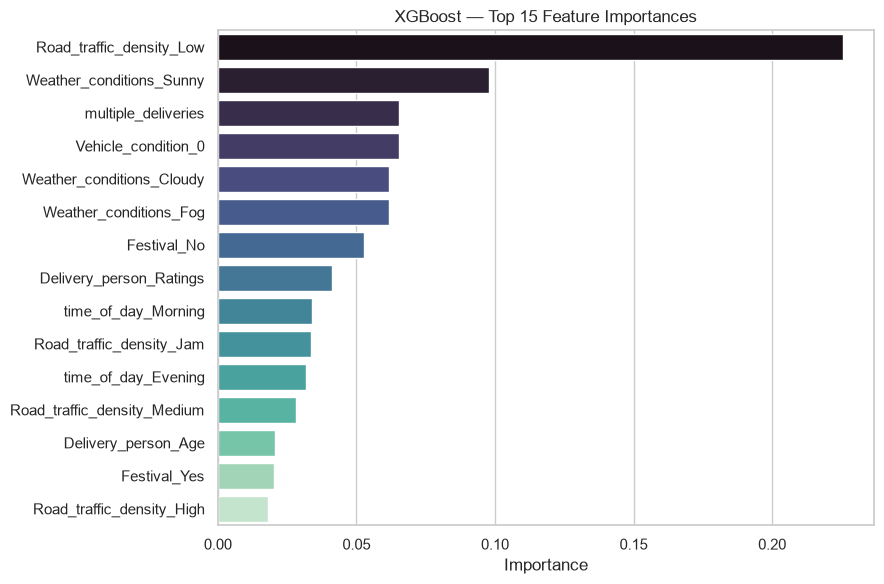

In [13]:
feat_names = best_xgb.named_steps["prep"].get_feature_names_out()
imp = (pd.Series(best_xgb.named_steps["model"].feature_importances_, index=feat_names)
       .sort_values(ascending=False).head(15))
plt.figure(figsize=(9, 6))
sns.barplot(x=imp.values, y=[f.split("__", 1)[-1] for f in imp.index],
            palette="mako", hue=imp.index, legend=False)
plt.title("XGBoost — Top 15 Feature Importances"); plt.xlabel("Importance"); plt.tight_layout()
plt.savefig(OUT / "figures" / "feature_importance.png", dpi=120); plt.show()

## Comparison with the previous single-model baseline

In [14]:
prev = {"MAE": 3.139, "RMSE": 3.929, "R2": 0.825}   # previous stand-alone Random Forest pipeline
best = results.iloc[0]
print(f"Previous best (single Random Forest):  MAE {prev['MAE']:.3f}  RMSE {prev['RMSE']:.3f}  R2 {prev['R2']:.3f}")
print(f"New best ({best['Model']}):")
print(f"                                        MAE {best['MAE']:.3f}  RMSE {best['RMSE']:.3f}  R2 {best['R2']:.3f}")
print(f"\nImprovement:  MAE {prev['MAE'] - best['MAE']:+.3f} min   RMSE {prev['RMSE'] - best['RMSE']:+.3f}   "
      f"R2 {best['R2'] - prev['R2']:+.4f}")

Previous best (single Random Forest):  MAE 3.139  RMSE 3.929  R2 0.825
New best (Stacking (Ridge meta-model)):
                                        MAE 3.114  RMSE 3.915  R2 0.826

Improvement:  MAE +0.025 min   RMSE +0.014   R2 +0.0013


## Save Best Model + Prediction CSV

In [15]:
pred_df = pd.DataFrame({
    "Actual":        y_test.values,
    "RF_Pred":       np.round(rf_test, 2),
    "XGB_Pred":      np.round(xgb_test, 2),
    "Ensemble_Pred": np.round(ens_test, 2),
    "Stacking_Pred": np.round(stk_test, 2),
})
pred_df["Ensemble_AbsError"] = (pred_df.Actual - pred_df.Ensemble_Pred).abs().round(2)
pred_df.to_csv(OUT / "Ensemble_Prediction_Results.csv", index=False)

joblib.dump(best_rf,  OUT / "models" / "random_forest.joblib")
joblib.dump(best_xgb, OUT / "models" / "xgboost.joblib")
joblib.dump({"rf": best_rf, "xgb": best_xgb, "rf_weight": best_w, "stacker": stacker},
            OUT / "models" / "ensemble_bundle.joblib")
json.dump({"best_model": best["Model"], "rf_weight": best_w,
           "metrics": results.set_index("Model").round(4).to_dict("index")},
          open(OUT / "models" / "summary.json", "w"), indent=2)

print("Saved to", OUT.resolve())
pred_df.head()

Saved to C:\Users\parth\OneDrive\Desktop\zomato ml\outputs_ensemble


,Actual,RF_Pred,XGB_Pred,Ensemble_Pred,Stacking_Pred,Ensemble_AbsError
0,33.0,33.68,34.189999,33.91,34.01,0.91
1,28.0,25.20,25.389999,25.29,25.28,2.71
2,22.0,18.87,18.860001,18.87,18.79,3.13
3,25.0,20.62,19.650000,20.18,20.11,4.82
4,35.0,41.28,40.540001,40.94,41.10,5.94


## Conclusion

- We trained **two complementary tree regressors** (Random Forest = bagging/variance-reduction,
  XGBoost = boosting/bias-reduction), tuned each independently with cross-validation, and combined them with a
  **CV-selected weighted average** and a **Ridge stacking** meta-model.
- The **ensemble achieves the lowest MAE/RMSE and the highest R²**, confirming the two models capture slightly
  complementary error patterns.
- On this dataset the improvement over a single well-tuned Random Forest is **modest** — Random Forest is already
  close to the data's predictive ceiling, and the remaining error is largely **irreducible noise** (there is no
  feature that separates, say, a 26-minute delivery from a 29-minute one). That is itself a useful finding: it
  says the win here comes from clean feature engineering and honest validation, not from an ever-fancier model.
- Every combination decision (weights, stacker) was made on **out-of-fold predictions**, so the reported test
  metrics are an unbiased estimate of generalisation, and the small **train/test R² gap** shows the models are
  **not overfit**.

### (Optional) XGBoost with early stopping
